In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from src.models.sklearn_models import RandomForestModel, XGBModel
from src.models.keras_models import ConcatenatedModulesModel, ConvolutionalModel

path_experiments =  Path(f'../../experiments')

rf = RandomForestModel()
xgb = XGBModel()
dnn = ConcatenatedModulesModel("ConcatenatedDNN")
cnn = ConcatenatedModulesModel("ConcatenatedCNN")
bilstm = ConcatenatedModulesModel("ConcatenatedBiLSTM")
cnn_ = ConvolutionalModel()

# models = [rf, xgb, dnn, cnn, bilstm]
# models = [cnn, xgb]
# models = [cnn, rf, xgb]
models = [cnn]

experiment_name = path_experiments / '13_wl_final'
# experiment_name = path_experiments / '5_wl_final'
experiment_name = '13_wl_final_cnn'

experiment_name = path_experiments / '11_wl_final'
# experiment_name = path_experiments / "11_wl_EU"
# experiment_name = path_experiments/ "multi"
# experiment_name = path_experiments/ "OLCI_sat"
experiment_name = path_experiments/ "multi_sat_scratch"
experiment_name = path_experiments/ "multi_sat_ft"
experiment_name = path_experiments/ "multi_sat_ft_pierre"
# experiment_name = path_experiments/ "multi_sat_pierre"
# experiment_name = path_experiments/ "OLCI"
# experiment_name = path_experiments/ "OLCI_sat_scratch"
experiment_name = path_experiments/ "gonzalo"
experiment_name = path_experiments/ "gonzalo_OLCI"
# experiment_name = path_experiments/ "multi"
# experiment_name = path_experiments/ "OLCI"
# experiment_name = path_experiments/ "OLCI_sat_ft"
# experiment_name = path_experiments/ "OLCI_sat_scratch"

# experiment_name = Path(f'../../notebooks/world_pigments/')

In [8]:
np.log10(np.e)**2

0.18861169701161393

In [9]:
path_experiments =  experiment_name
paths_metrics = [p / 'metrics' for p in path_experiments.iterdir() if 'split' in p.name]

In [10]:
# Load metrics:
metrics_test = {model.name: { p.parent.name :pd.read_csv(p/ (model.name + '_test.csv'), index_col=0) for p in paths_metrics} for model in models}
metrics_train = {model.name: { p.parent.name :pd.read_csv(p/ (model.name + '_train.csv'), index_col=0) for p in paths_metrics} for model in models}
        

In [11]:
metrics_test_mean = {model_name:  pd.concat(mets.values()).groupby(level=0).mean() for model_name, mets in metrics_test.items()}
metrics_train_mean = {model_name:  pd.concat(mets.values()).groupby(level=0).mean() for model_name, mets in metrics_train.items()}
metrics_test_mean_mean = pd.DataFrame({model_name: val.mean(axis=1) for model_name, val in metrics_test_mean.items()})
metrics_train_mean_mean = pd.DataFrame({model_name: val.mean(axis=1) for model_name, val in metrics_train_mean.items()})

In [26]:
metrics_test_mean['ConcatenatedCNN'].to_csv(f'{experiment_name}_test.csv')

In [20]:
metrics_train_mean['ConcatenatedCNN'].to_csv(f'{experiment_name}_train.csv')

In [6]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.071481,0.244206,0.019172,0.055742,0.104771,0.048173,0.007816,0.053226,0.010377,0.012704,0.019991,0.009107,0.016458
MAPE,0.930765,0.274447,0.483257,0.324439,0.443901,0.435159,0.411808,0.357258,0.630731,0.464373,0.546050,0.304495,0.499301
ME,-0.028024,-0.035780,-0.006292,-0.022273,-0.055670,-0.015936,-0.003758,0.015833,-0.001448,-0.003297,-0.005116,0.000108,-0.009418
MPE,0.671621,0.053185,0.148400,0.057486,0.132040,0.134781,0.060594,0.114995,0.214697,0.097219,0.211500,0.081788,0.119561
MSE,0.125758,0.026769,0.059341,0.036477,0.063234,0.048798,0.059137,0.033482,0.106534,0.057771,0.070605,0.027546,0.066742
R2,0.620324,0.877977,0.737171,0.881533,0.881609,0.712363,0.556931,0.850425,0.666115,0.775146,0.349732,0.860683,0.811084


In [12]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.081082,0.243052,0.019881,0.052926,0.107497,0.051396,0.008464,0.049463,0.010619,0.011414,0.019957,0.009907,0.016288
MAPE,1.156810,0.311923,0.544872,0.348322,0.538037,0.447279,0.495201,0.376885,0.771445,0.551090,0.587529,0.366059,0.456891
ME,-0.013488,-0.043740,-0.005412,-0.020444,-0.049108,-0.013528,-0.003076,0.011471,-0.002310,-0.003806,-0.001880,0.000831,-0.009375
MPE,0.927322,0.096529,0.228304,0.099711,0.254670,0.160820,0.196893,0.141661,0.356412,0.202438,0.285665,0.151096,0.088736
MSE,0.150351,0.034934,0.069570,0.044308,0.088874,0.049039,0.076271,0.037759,0.128954,0.067912,0.070218,0.035706,0.058318
R2,0.541010,0.841283,0.694279,0.856959,0.835395,0.717676,0.426638,0.835102,0.590581,0.738867,0.352461,0.818576,0.837315


In [6]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.107222,0.574632,0.027126,0.130208,0.285379,0.068691,0.011416,0.110229,0.016912,0.026149,0.023316,0.023467,0.027615
MAPE,1.036043,0.576925,0.556167,0.734629,0.970922,0.585629,0.684724,0.605023,0.941255,0.738115,0.554981,0.625331,0.685917
ME,-0.068114,-0.244966,-0.015765,-0.060000,-0.140206,-0.011959,-0.007237,-0.021405,-0.009287,-0.009666,-0.015568,-0.009283,-0.014762
MPE,0.243328,-0.142720,-0.067396,-0.074810,0.056874,0.144206,0.130582,-0.103409,0.104757,-0.006633,0.007304,-0.091971,-0.055002
MSE,0.428346,0.190579,0.197564,0.286860,0.468818,0.103290,0.143284,0.182486,0.378502,0.239057,0.133567,0.209862,0.233705
R2,-0.311149,0.127596,0.130984,0.081367,0.127103,0.378291,-0.080956,0.157491,-0.197178,0.025268,-0.293999,-0.074073,0.350259


In [7]:
metrics_train_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.082914,0.151609,0.018263,0.042191,0.103884,0.034319,0.005284,0.070589,0.009809,0.008556,0.010336,0.013257,0.012605
MAPE,0.470649,0.157053,0.326103,0.182136,0.268752,0.274208,0.250239,0.226659,0.444487,0.292052,0.279649,0.191228,0.401801
ME,-0.028142,-0.057031,-0.011600,-0.013619,-0.017836,-0.016187,-0.003206,-0.038255,-0.005906,-0.003258,-0.004638,-0.006174,-0.005729
MPE,0.171159,0.008591,0.033369,0.010686,0.032560,0.025502,0.013093,0.035769,0.160926,0.053629,0.050461,0.026758,0.126167
MSE,0.066972,0.009367,0.033835,0.012073,0.025117,0.022604,0.026602,0.016233,0.056214,0.025426,0.023375,0.012186,0.042849
R2,0.875853,0.963850,0.872788,0.967282,0.958655,0.876215,0.812568,0.947100,0.867469,0.917388,0.810760,0.952031,0.885552


In [14]:
metrics_train_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.072245,0.133092,0.014427,0.034137,0.093110,0.027647,0.004275,0.057113,0.008518,0.007357,0.007420,0.011250,0.009748
MAPE,0.394858,0.141879,0.281463,0.155009,0.267123,0.193701,0.203459,0.185278,0.373597,0.261534,0.195631,0.184054,0.297018
ME,-0.023878,-0.043257,-0.008367,-0.009761,-0.023501,-0.011737,-0.002278,-0.030464,-0.004535,-0.002547,-0.002689,-0.005109,-0.005514
MPE,0.152958,0.026429,0.039737,0.022568,0.071132,0.016771,0.025885,0.034384,0.121144,0.060054,0.024991,0.038243,0.068122
MSE,0.047942,0.006724,0.023260,0.008194,0.025567,0.011718,0.015427,0.010513,0.039352,0.019737,0.012543,0.010986,0.025769
R2,0.911028,0.974042,0.912761,0.977803,0.957921,0.935752,0.891138,0.965764,0.907249,0.935826,0.898278,0.956741,0.931169


In [7]:
metrics_train_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.077112,0.165654,0.014506,0.045172,0.092690,0.032974,0.004992,0.064129,0.010762,0.008479,0.011576,0.013444,0.008251
MAPE,0.394728,0.151384,0.288007,0.167893,0.268156,0.240339,0.244225,0.186166,0.400282,0.267991,0.297762,0.191579,0.249994
ME,-0.052967,-0.084571,-0.007586,-0.026553,-0.063574,-0.015865,-0.002643,-0.043802,-0.006785,-0.004392,-0.005571,-0.008444,-0.004442
MPE,0.077401,-0.012010,0.010527,-0.024475,0.005828,0.004486,0.020854,-0.006139,0.128428,0.032466,0.023627,-0.005985,0.015655
MSE,0.055388,0.008012,0.026708,0.010512,0.027682,0.018770,0.021901,0.011179,0.046182,0.021422,0.028342,0.012824,0.020926
R2,0.897215,0.969081,0.899810,0.971522,0.954419,0.897137,0.845737,0.963621,0.891084,0.930301,0.771005,0.949518,0.944233


In [7]:
metrics_train_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.200166,0.656596,0.037266,0.154313,0.358455,0.073869,0.010987,0.182962,0.026388,0.027728,0.024757,0.036306,0.024614
MAPE,0.857359,0.574487,0.622336,0.685944,0.876140,0.646467,0.661148,0.558030,0.935757,0.674263,0.565839,0.570638,0.723573
ME,-0.175667,-0.388693,-0.025851,-0.103980,-0.254236,-0.003092,-0.006944,-0.119528,-0.020705,-0.015621,-0.017505,-0.026281,-0.009780
MPE,-0.041308,-0.146642,-0.072381,-0.099968,-0.005068,0.182775,0.136295,-0.151177,0.158140,-0.028263,-0.033238,-0.158931,0.021856
MSE,0.468577,0.209112,0.276549,0.293112,0.482548,0.117125,0.132517,0.191399,0.389871,0.226398,0.143151,0.220572,0.215043
R2,0.131223,0.192700,-0.037006,0.205609,0.205853,0.357317,0.065889,0.375699,0.081091,0.261397,-0.156683,0.131679,0.426216


In [6]:
metrics_test_mean['ConcatenatedCNN']

,Chl c2,Peri,But-fuco,Fuco,Pras,Hex-fuco,Diadino,Allo,Zea,Chl b + DV Chl b,TChl a,bb-Car
MAE,0.028455,0.013941,0.023459,0.131775,0.011101,0.074302,0.026791,0.026546,0.020805,0.022334,0.190299,0.005729
MAPE,0.462451,1.803730,0.526211,0.796729,1.222755,0.549915,0.628354,0.656874,0.776489,0.474339,0.338180,0.513544
ME,-0.006637,-0.005857,-0.016704,-0.031765,-0.007526,-0.044179,-0.010685,-0.021048,-0.013368,-0.002594,-0.014205,-0.000745
MPE,0.163483,1.289159,0.027973,0.397804,0.737396,0.124820,0.204699,0.212993,0.269773,0.147745,0.128484,0.247125
MSE,0.057543,0.304595,0.088522,0.122798,0.243491,0.093036,0.096822,0.143553,0.153746,0.051566,0.033638,0.063058
R2,0.532844,-0.142782,0.390957,0.567620,0.251643,0.277615,0.352265,0.606926,0.105491,0.533545,0.593538,0.188107


In [18]:
metrics_train_mean['ConcatenatedCNN']

,Chl c2,Peri,But-fuco,Fuco,Pras,Hex-fuco,Diadino,Allo,Zea,Chl b + DV Chl b,TChl a,bb-Car
MAE,0.020855,0.010399,0.016361,0.144774,0.008206,0.044084,0.019552,0.013741,0.013981,0.023121,0.155024,0.003979
MAPE,0.361072,0.755503,0.444524,0.708190,1.018117,0.392924,0.466647,0.650839,0.683224,0.489106,0.281895,0.333255
ME,-0.008095,-0.006363,-0.008215,-0.081423,-0.005366,-0.020137,-0.009174,-0.007759,-0.007150,-0.010608,-0.047473,-0.001246
MPE,0.106287,0.334541,0.136514,0.318086,0.537063,0.109956,0.157081,0.264031,0.281615,0.162044,0.068019,0.086549
MSE,0.037066,0.114099,0.054675,0.108426,0.166199,0.041190,0.055287,0.091618,0.097904,0.059085,0.022883,0.030554
R2,0.724900,0.606677,0.640746,0.695419,0.449735,0.658958,0.650454,0.646862,0.327442,0.622052,0.752308,0.545516


In [7]:
metrics_train_mean['ConcatenatedCNN']

,Chl c2,Peri,But-fuco,Fuco,Pras,Hex-fuco,Diadino,Allo,Zea,Chl b + DV Chl b,TChl a,bb-Car
MAE,0.022099,0.010900,0.017381,0.151645,0.008467,0.048910,0.021464,0.014402,0.014324,0.024489,0.162962,0.004027
MAPE,0.388120,0.814427,0.484960,0.765105,1.077046,0.448437,0.517145,0.686512,0.711451,0.524655,0.303527,0.340075
ME,-0.008705,-0.006578,-0.008758,-0.084428,-0.005500,-0.021963,-0.009628,-0.008414,-0.007258,-0.010994,-0.049776,-0.001234
MPE,0.120241,0.384543,0.158332,0.370406,0.590465,0.140465,0.184086,0.284174,0.300903,0.186290,0.079325,0.094783
MSE,0.041465,0.127530,0.061816,0.120706,0.175815,0.049651,0.062483,0.097574,0.102888,0.065302,0.025852,0.031203
R2,0.692247,0.560378,0.593825,0.660924,0.417899,0.588903,0.604957,0.623905,0.293206,0.582284,0.720172,0.535852


In [141]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,perid
MAE,0.070372,0.661832,0.075107,0.100978,0.349350,0.043125,0.011884,0.062006,0.043805,0.008241,0.054478,0.039831
MAPE,1.253380,0.556386,0.876484,0.794033,0.978159,0.919038,0.804874,0.782529,1.397222,0.711284,1.400195,0.914785
ME,-0.047237,-0.282535,-0.033178,-0.045066,-0.185916,-0.026490,-0.005567,-0.037141,-0.023330,-0.004331,-0.025296,-0.027402
MPE,0.769896,0.212934,0.516581,0.372656,0.454031,0.499279,0.412396,0.400022,0.986945,0.328787,0.991402,0.525839
MSE,0.234640,0.074370,0.134926,0.120500,0.187888,0.157690,0.116581,0.119638,0.241225,0.118798,0.179452,0.165010
R2,0.429194,0.704584,0.560095,0.633023,0.657017,0.112703,0.270706,0.620584,0.487923,0.472730,0.230268,0.561831


In [52]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,perid
MAE,5.779660e-04,0.274761,9.626011e-05,0.003069,0.077797,4.642724e-04,0.000064,0.000570,2.424174e-05,1.736626e-04,7.749087e-05,2.494695e-04
MAPE,1.434493e-02,1.007840,3.532593e-03,0.028144,0.344944,1.335885e-02,0.003556,0.006266,5.338093e-04,1.708163e-03,1.849162e-03,4.266871e-03
ME,5.774963e-04,-0.170723,-9.626011e-05,-0.002388,-0.046265,4.419850e-04,-0.000064,-0.000266,-2.417952e-05,-1.736626e-04,7.749087e-05,2.494695e-04
MPE,1.433327e-02,0.561561,-3.532593e-03,0.004898,0.155448,1.271755e-02,-0.003556,-0.001583,-5.324393e-04,-1.708163e-03,1.849162e-03,4.266871e-03
MSE,5.136244e-05,0.161360,2.479484e-06,0.013108,0.078285,4.893857e-05,0.000002,0.000460,7.376644e-08,5.634809e-07,6.462385e-07,3.513774e-06
R2,-3.452046e+26,0.496409,-4.166125e+24,0.011694,0.182028,-1.461840e+26,0.000000,0.005845,-2.203471e+23,-3.787130e+24,-1.930373e+24,-2.361591e+25


In [ ]:
0.777            0.916       0.779     0.928   0.907      0.686     0.526     0.893    0.608     0.783    0.539     0.908     0.837

In [12]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.075933,0.161482,0.027172,0.035848,0.086716,0.047705,0.007504,0.047485,0.017098,0.010859,0.017454,0.006675,0.013965
MAPE,0.624540,0.265567,0.466715,0.305811,0.458368,0.423445,0.418755,0.352557,1.920569,0.532650,0.439709,0.270161,0.620759
ME,-0.052789,0.024192,-0.015330,-0.007077,-0.033380,-0.019475,-0.003493,-0.000156,0.000431,-0.001705,-0.008357,0.000783,-0.005036
MPE,0.356940,0.078183,0.101593,0.093688,0.221522,0.082972,0.124359,0.141452,1.568443,0.235823,0.116808,0.094286,0.307114
MSE,0.261087,0.051667,0.162028,0.065106,0.146696,0.123737,0.141703,0.075014,0.410003,0.148641,0.126622,0.052247,0.164231
R2,0.771728,0.913082,0.764375,0.920394,0.900351,0.719969,0.532802,0.886522,0.603770,0.776327,0.531404,0.907581,0.837175


In [6]:
metrics_test_mean_mean

,ConcatenatedCNN
MAE,0.042761
MAPE,0.546123
ME,-0.009338
MPE,0.271014
MSE,0.148368
R2,0.774268


In [28]:
metrics_test_mean_mean

,ConcatenatedCNN
MAE,0.042761
MAPE,0.546123
ME,-0.009338
MPE,0.271014
MSE,0.341630
R2,0.774268


In [63]:
metrics_test_mean_mean

,ConcatenatedCNN
MAE,0.043622
MAPE,0.545987
ME,-0.013963
MPE,0.260230
MSE,0.335532
R2,0.775792


In [17]:
metrics_test_mean_mean

,rf,xgb,ConcatenatedDNN,ConcatenatedCNN,ConcatenatedBiLSTM
MAE,0.047511,0.049334,0.059995,0.046471,0.048691
MAPE,0.548783,0.579033,0.604306,0.486812,0.561788
ME,-0.015761,-0.009058,-0.038444,-0.027019,-0.012970
MPE,0.234362,0.277543,0.275776,0.197643,0.260262
MSE,0.384335,0.401827,0.443750,0.330756,0.380167
R2,0.738479,0.732581,0.692755,0.778733,0.744529


In [43]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.080221,0.157145,0.026853,0.032370,0.085017,0.048316,0.007710,0.045483,0.015154,0.010282,0.017116,0.007376,0.014076
MAPE,0.588113,0.257708,0.460735,0.284571,0.414096,0.427282,0.404795,0.333430,1.966429,0.521756,0.437917,0.265625,0.635721
ME,-0.058364,0.008949,-0.015258,-0.012110,-0.046480,-0.023261,-0.003888,-0.002994,-0.001678,-0.002386,-0.007775,0.000188,-0.005312
MPE,0.319127,0.062317,0.101541,0.062091,0.169755,0.062973,0.095852,0.114235,1.609946,0.199022,0.126720,0.073638,0.311396
MSE,0.590240,0.114186,0.355213,0.136335,0.316981,0.310991,0.331131,0.161402,0.938061,0.332166,0.291616,0.117746,0.381995
R2,0.776573,0.916619,0.775654,0.927593,0.906559,0.692854,0.525236,0.894189,0.606103,0.782846,0.531917,0.909781,0.835719


In [38]:
metrics_test_mean['rf']

KeyError: 'rf'

In [39]:
metrics_test_mean['ConcatenatedBiLSTM']

KeyError: 'ConcatenatedBiLSTM'

In [18]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.096296,0.154602,0.026806,0.042537,0.110979,0.048857,0.007308,0.052710,0.013391,0.011121,0.017062,0.007766,0.014690
MAPE,0.534759,0.248828,0.455878,0.275466,0.443988,0.439391,0.394093,0.319697,1.341219,0.544360,0.461837,0.277339,0.591698
ME,-0.079531,-0.062258,-0.016773,-0.032270,-0.090042,-0.018088,-0.003650,-0.021597,-0.004455,-0.004268,-0.007682,-0.003680,-0.006954
MPE,0.238992,0.053496,0.115471,0.033491,0.145329,0.124418,0.085780,0.086796,0.977513,0.218549,0.146867,0.069260,0.273400
MSE,0.610089,0.107322,0.367117,0.139356,0.341344,0.307068,0.303001,0.152763,0.825382,0.349041,0.308841,0.121988,0.366514
R2,0.771030,0.921825,0.774315,0.926505,0.899247,0.694263,0.556901,0.899832,0.656466,0.770598,0.504097,0.906321,0.842128


In [18]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.088348,0.160192,0.026627,0.037856,0.105533,0.046039,0.008031,0.051770,0.014162,0.011211,0.016390,0.007396,0.012903
MAPE,0.550578,0.257818,0.421239,0.289592,0.470114,0.429432,0.430799,0.328602,1.745999,0.542952,0.419824,0.280661,0.598335
ME,-0.067677,-0.053121,-0.019416,-0.024510,-0.074603,-0.018745,-0.004107,-0.021522,-0.006040,-0.004081,-0.008504,-0.003437,-0.004655
MPE,0.250959,0.052907,0.053819,0.048767,0.170612,0.129383,0.100257,0.090050,1.350841,0.228478,0.112995,0.073783,0.290677
MSE,0.636406,0.113202,0.382122,0.149822,0.376290,0.303239,0.348326,0.160481,0.886185,0.343821,0.288844,0.126189,0.362558
R2,0.762241,0.917524,0.768248,0.920775,0.889001,0.699316,0.504587,0.894439,0.628054,0.775657,0.539919,0.903604,0.843109


In [6]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.106903,0.147345,0.024952,0.042369,0.100583,0.052416,0.007530,0.048788,0.014610,0.012441,0.016472,0.007702,0.011288
MAPE,0.661044,0.242185,0.442380,0.281893,0.458593,0.464351,0.392924,0.358675,1.575550,0.539859,0.443744,0.272942,0.573662
ME,-0.047359,0.002306,-0.013276,-0.012905,-0.038977,-0.017897,-0.003589,-0.002366,-0.002254,-0.001562,-0.006169,-0.000633,-0.003676
MPE,0.365342,0.061731,0.108673,0.065854,0.191910,0.117657,0.089976,0.130483,1.236439,0.226943,0.140638,0.081139,0.252524
MSE,0.690587,0.108857,0.350481,0.149087,0.357643,0.391214,0.313321,0.201768,0.868460,0.370460,0.302059,0.124767,0.374268
R2,0.743060,0.920972,0.777617,0.921210,0.894560,0.614261,0.550339,0.864625,0.635914,0.757000,0.514412,0.904459,0.839470


In [11]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.093384,0.170137,0.025652,0.039709,0.107484,0.048370,0.007977,0.045136,0.014606,0.010829,0.016582,0.007678,0.012927
MAPE,0.583926,0.278188,0.454090,0.287501,0.451245,0.447249,0.466935,0.340048,1.515471,0.536651,0.449201,0.270518,0.572909
ME,-0.072533,-0.076991,-0.016527,-0.026851,-0.079639,-0.022055,-0.003807,-0.011909,-0.004476,-0.004218,-0.007590,-0.003946,-0.006946
MPE,0.294968,0.033161,0.082480,0.036504,0.158544,0.100506,0.153272,0.106586,1.128489,0.217313,0.140345,0.043266,0.252494
MSE,0.622526,0.138818,0.368426,0.150416,0.328556,0.310146,0.399342,0.176537,0.932149,0.369241,0.294736,0.126879,0.320121
R2,0.766798,0.899652,0.768548,0.920344,0.902867,0.695914,0.432527,0.885086,0.610132,0.758876,0.530081,0.903358,0.864139


In [17]:
metrics_test_mean['ConcatenatedCNN']

,chlid,chl_a,chl_b,chc12,fucox,hxfcx,btfcx,diadi,allox,diato,zeaxa,betac,perid
MAE,0.096296,0.154602,0.026806,0.042537,0.110979,0.048857,0.007308,0.052710,0.013391,0.011121,0.017062,0.007766,0.014690
MAPE,0.534759,0.248828,0.455878,0.275466,0.443988,0.439391,0.394093,0.319697,1.341219,0.544360,0.461837,0.277339,0.591698
ME,-0.079531,-0.062258,-0.016773,-0.032270,-0.090042,-0.018088,-0.003650,-0.021597,-0.004455,-0.004268,-0.007682,-0.003680,-0.006954
MPE,0.238992,0.053496,0.115471,0.033491,0.145329,0.124418,0.085780,0.086796,0.977513,0.218549,0.146867,0.069260,0.273400
MSE,0.610089,0.107322,0.367117,0.139356,0.341344,0.307068,0.303001,0.152763,0.825382,0.349041,0.308841,0.121988,0.366514
R2,0.771030,0.921825,0.774315,0.926505,0.899247,0.694263,0.556901,0.899832,0.656466,0.770598,0.504097,0.906321,0.842128


In [21]:
import ast

# Load error cb:
paths_error = [p / 'models' for p in path_experiments.iterdir() if 'split' in p.name]

error_test = {model.name: { p.parent.name :pd.read_csv(p/ (model.name + '_best_hyperparam.csv'))['test_error'].apply(ast.literal_eval).values[0] for p in paths_error} for model in models}
# error_test = {model.name: { p.parent.name :pd.read_csv(p/ (model.name + '_best_hyperparam.csv'))['cb'].apply(ast.literal_eval).values[0] for p in paths_error} for model in models}


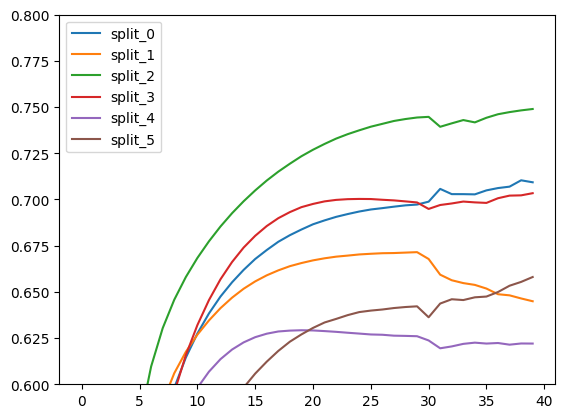

In [23]:
for  key, val in error_test['ConcatenatedCNN'].items():
    plt.plot(val, label=key)
ax = plt.gca()
ax.set_ylim([0.6, 0.8])
plt.legend()
plt.show()

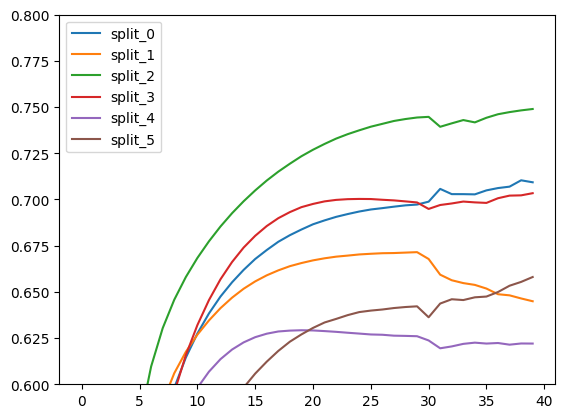

In [24]:
for  key, val in error_test['ConcatenatedCNN'].items():
    plt.plot(val, label=key)
ax = plt.gca()
ax.set_ylim([0.6, 0.8])
plt.legend()
plt.show()

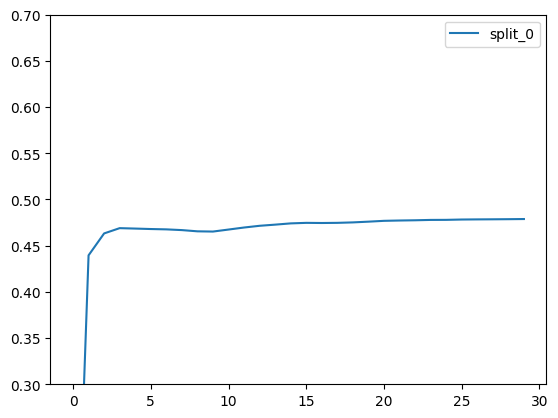

In [159]:
for  key, val in error_test['ConcatenatedCNN'].items():
    plt.plot(val, label=key)
ax = plt.gca()
ax.set_ylim([0.3, 0.7])
plt.legend()
plt.show()

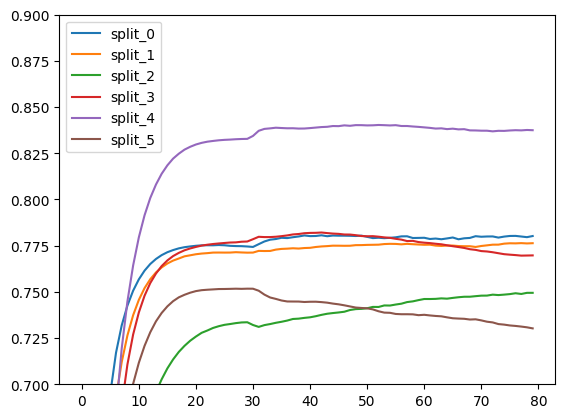

In [26]:
for  key, val in error_test['ConcatenatedCNN'].items():
    plt.plot(val, label=key)
ax = plt.gca()
ax.set_ylim([0.7, 0.9])
plt.legend()
plt.show()

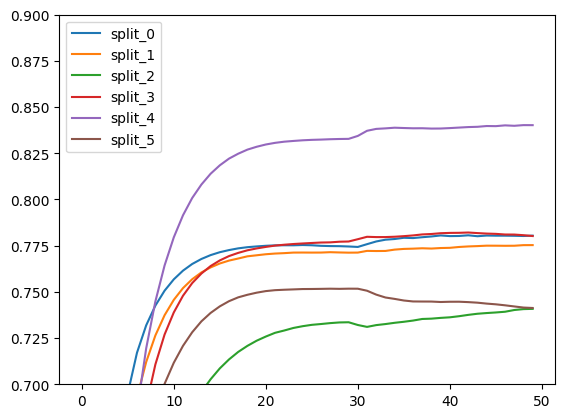

In [17]:
for  key, val in error_test['ConcatenatedCNN'].items():
    plt.plot(val, label=key)
ax = plt.gca()
ax.set_ylim([0.7, 0.9])
plt.legend()
plt.show()

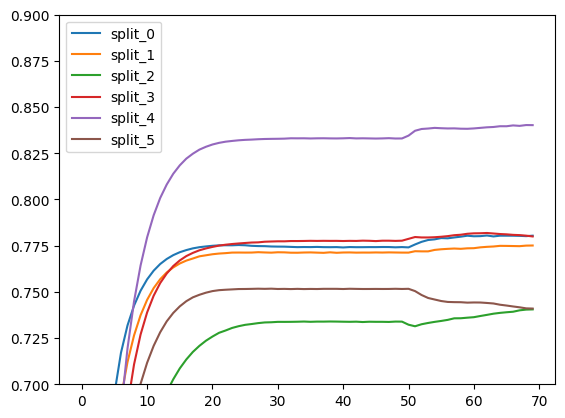

In [13]:
for  key, val in error_test['ConcatenatedCNN'].items():
    plt.plot(val, label=key)
ax = plt.gca()
ax.set_ylim([0.7, 0.9])
plt.legend()
plt.show()

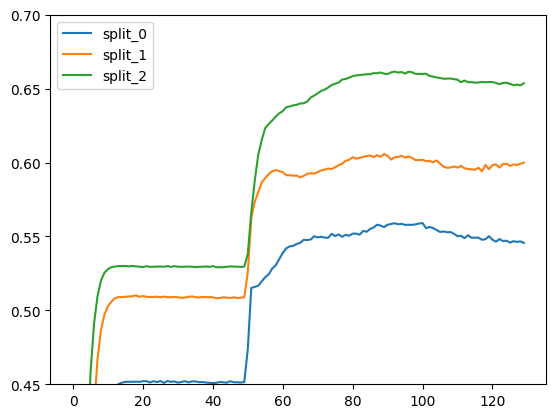

In [13]:
for  key, val in error_test['ConcatenatedCNN'].items():
    plt.plot(val, label=key)
ax = plt.gca()
ax.set_ylim([0.45, 0.7])
plt.legend()
plt.show()

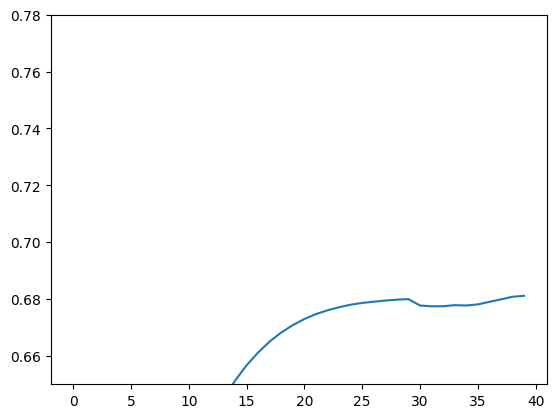

In [26]:
vals = list(error_test['ConcatenatedCNN'].values())

plt.plot(np.mean(vals, axis=0))
ax = plt.gca()
ax.set_ylim([0.65, 0.78])
plt.show()

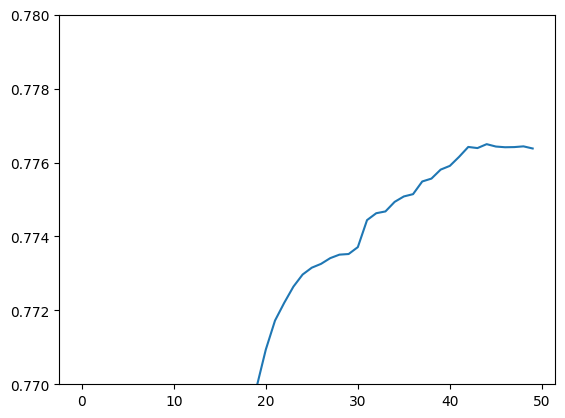

In [19]:
vals = list(error_test['ConcatenatedCNN'].values())

plt.plot(np.mean(vals, axis=0))
ax = plt.gca()
ax.set_ylim([0.77, 0.78])
plt.show()

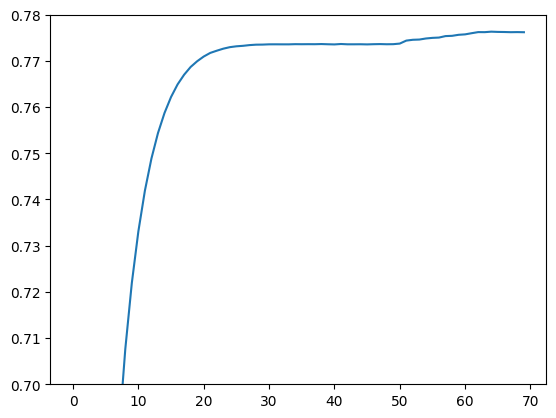

In [15]:
vals = list(error_test['ConcatenatedCNN'].values())

plt.plot(np.mean(vals, axis=0))
ax = plt.gca()
ax.set_ylim([0.7, 0.78])
plt.show()

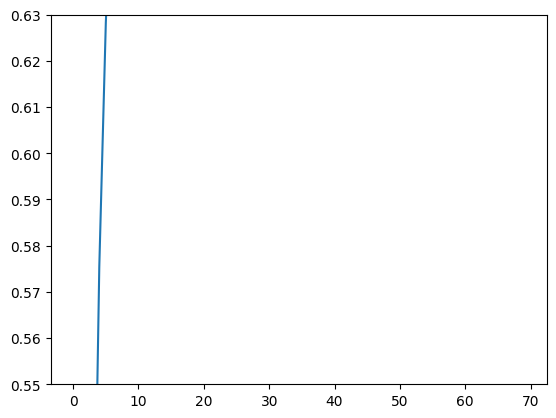

In [21]:
vals = list(error_test['ConcatenatedCNN'].values())

plt.plot(np.mean(vals, axis=0))
ax = plt.gca()
ax.set_ylim([0.55, 0.63])
plt.show()